In [42]:
# Load packages
import os
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
from scipy.sparse import issparse
from sklearn.model_selection import train_test_split

In [8]:
# Load data
data_dir = '../data/frangieh/'
adata = sc.read_h5ad(data_dir + 'adata_preprocessed.h5ad')

In [9]:
# Feature Selection
adata_hvg = adata[:, adata.var["highly_variable"]].copy()

# Save the HVG names
shared_hvgs = adata.var_names[adata.var["highly_variable"]]
print("Number of shared HVGs:", len(shared_hvgs))

Number of shared HVGs: 2000


In [10]:
# split data by condition
adata_control = adata[adata.obs['condition'] == 'Control']
adata_ifng = adata[adata.obs['condition'] == 'IFNγ']
adata_coculture = adata[adata.obs['condition'] == 'Co-culture']

adata_control_hvg = adata_hvg[
    adata_hvg.obs["condition"] == "Control",
    shared_hvgs
].copy()

adata_ifng_hvg = adata_hvg[
    adata_hvg.obs["condition"] == "IFNγ",
    shared_hvgs
].copy()

adata_coculture_hvg = adata_hvg[
    adata_hvg.obs["condition"] == "Co-culture",
    shared_hvgs
].copy()

In [11]:
all_data = {"control": adata_control, "ifng": adata_ifng, "coculture": adata_coculture}

## Pseudobulk and compute log fold change

In [12]:
def compute_pseudobulk_lfc(
    adata: ad.AnnData,
    cond_key: str = 'condition',
    pert_key: str = 'perturbation',
    control_label: str = 'control',
    min_cells: int = 5,
    pseudocount: float = 1e-6,
    data_type: str = 'counts',
) -> ad.AnnData:
    """
    Computes pseudobulk log2 fold changes (LFC) per perturbation relative to controls within each condition.
    
    Parameters
    ----------
    adata : ad.AnnData
        Single-cell AnnData object (log1p normalized or raw counts in .X).
    cond_key : str
        Observation key for experimental conditions (e.g., 'Control', 'IFNγ', 'Co-culture').
    pert_key : str
        Observation key for perturbation target labels.
    control_label : str
        Label indicating unperturbed control cells within pert_key.
    min_cells : int
        Minimum number of cells required per perturbation group to keep it.
    pseudocount : float
        Small offset added to linear means to prevent zero-division in log2 ratio.
    data_type : str
        Either 'counts' or 'log1p'. Specifies the type of data in adata.X.

    Returns
    -------
    ad.AnnData
        Pseudobulk AnnData object containing Log2 Fold Changes in .X,
        retained perturbation/condition metadata in .obs, and gene annotations in .var.
    """

    # 1. Clean up labels
    obs_df = adata.obs.copy()
    obs_df[pert_key] = obs_df[pert_key].astype(str).str.strip().str.lower()
    ctrl_label_clean = str(control_label).strip().lower()

    # 2. Filter perturbations with fewer than min_dataset_cells across the entire dataset
    if min_cells > 0:
        dataset_counts = obs_df[pert_key].value_counts()
        valid_dataset_perts = dataset_counts[
            dataset_counts >= min_cells
        ].index
        cell_mask = obs_df[pert_key].isin(valid_dataset_perts).values

        adata_filtered = adata[cell_mask].copy()
        obs_df = obs_df[cell_mask].copy()
    else:
        adata_filtered = adata.copy()
    
    # 3. Extract expression matrix (linearize if log1p) or use raw counts
    if data_type == "log1p":
        if issparse(adata_filtered.X):
            X_linear = adata_filtered.X.copy().astype(np.float64)
            X_linear.data = np.expm1(X_linear.data)
            X_linear.data = np.nan_to_num(
                X_linear.data, nan=0.0, posinf=0.0, neginf=0.0
            )
            X_linear.data[X_linear.data < 0] = 0.0
            X_linear.eliminate_zeros()
        else:
            X_linear = np.expm1(
                np.asarray(adata_filtered.X, dtype=np.float64)
            )
            X_linear = np.nan_to_num(X_linear, nan=0.0, posinf=0.0, neginf=0.0)
            X_linear[X_linear < 0] = 0.0
    elif data_type == "counts":
        if issparse(adata_filtered.X):
            X_linear = adata_filtered.X.copy().astype(np.float64)
            X_linear.data = np.nan_to_num(
                X_linear.data, nan=0.0, posinf=0.0, neginf=0.0
            )
            X_linear.data[X_linear.data < 0] = 0.0
            X_linear.eliminate_zeros()
        else:
            X_linear = np.asarray(adata_filtered.X, dtype=np.float64)
            X_linear = np.nan_to_num(X_linear, nan=0.0, posinf=0.0, neginf=0.0)
            X_linear[X_linear < 0] = 0.0
    else:
        X_linear = adata_filtered.X.copy()

    lfc_matrices = []
    obs_metadata_list = []

    # 4. Process each condition independently without per-condition min_cells filtering
    for cond_val, cond_obs in obs_df.groupby(cond_key):
        cond_indices = cond_obs.index
        cond_mask = obs_df.index.isin(cond_indices)

        # Extract linear matrix subset for this condition
        X_cond = X_linear[cond_mask, :]
        cond_perts = obs_df.loc[cond_indices, pert_key].values
        pert_counts_in_cond = cond_obs[pert_key].value_counts()

        # Locate control cells in this condition
        ctrl_mask = cond_perts == ctrl_label_clean
        if not np.any(ctrl_mask):
            print(
                f"Skipping condition '{cond_val}': No control cells"
                f" ('{ctrl_label_clean}') found."
            )
            continue

        # Compute mean linear profile for control
        if issparse(X_cond):
            ctrl_mean = np.asarray(X_cond[ctrl_mask, :].mean(axis=0)).ravel()
        else:
            ctrl_mean = X_cond[ctrl_mask, :].mean(axis=0)

        # Target all non-control perturbations present in this condition
        target_perts = [
            p for p in np.unique(cond_perts) if p != ctrl_label_clean
        ]

        cond_lfc_list = []
        retained_obs = []

        for pert in target_perts:
            p_mask = cond_perts == pert

            if issparse(X_cond):
                p_mean = np.asarray(X_cond[p_mask, :].mean(axis=0)).ravel()
            else:
                p_mean = X_cond[p_mask, :].mean(axis=0)

            # Calculate standard Log2 Fold Change
            lfc = np.log2((p_mean + pseudocount) / (ctrl_mean + pseudocount))
            cond_lfc_list.append(lfc)

            # Metadata tracking
            sample_obs_row = cond_obs[
                cond_obs[pert_key] == pert
            ].iloc[0].to_dict()
            sample_obs_row["n_cells_pseudobulk"] = pert_counts_in_cond[pert]
            retained_obs.append(sample_obs_row)

        if len(cond_lfc_list) > 0:
            lfc_matrices.append(np.vstack(cond_lfc_list))
            obs_metadata_list.extend(retained_obs)

    if not lfc_matrices:
        raise ValueError(
            "No valid perturbation groups could be computed across conditions."
        )

    # 5. Concatenate and return AnnData
    final_lfc_matrix = np.vstack(lfc_matrices)
    final_obs_df = pd.DataFrame(obs_metadata_list)
    final_obs_df.index = [
        f"{row[cond_key]}_{row[pert_key]}" for row in obs_metadata_list
    ]

    lfc_adata = ad.AnnData(
        X=final_lfc_matrix, obs=final_obs_df, var=adata_filtered.var.copy()
    )
    lfc_adata.uns["lfc_baseline_label"] = control_label
    lfc_adata.uns["pseudocount"] = pseudocount

    return lfc_adata

# Control condition

In [22]:
adata_control_hvg_lfc = compute_pseudobulk_lfc(
    adata=adata_control_hvg,
    cond_key='condition',
    pert_key='perturbation',
    control_label='control',
    min_cells=20,
    pseudocount=1e-6,
    data_type='counts'
)

## Select Pertrubations and Test/Train Split

3 Ideas for splitting:
A. 50 perturbations with highest cell counts
B. random split
C. 50 perturbations with highest lfc
D. cluster and choose representatives from each cluster
E. Select perturbations with the most occurences in the MSigDB_Hallmark_2020 database pathways

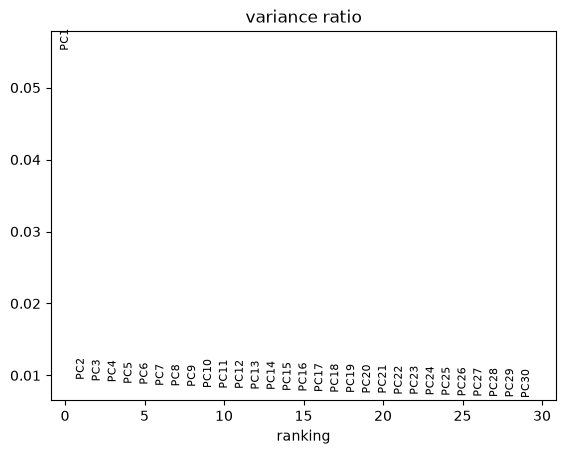

In [23]:
# Compute PCA
# Find optimal number of PCs to use for clustering using the elbow method
sc.pp.pca(adata_control_hvg_lfc, n_comps=30)
sc.pl.pca_variance_ratio(adata_control_hvg_lfc, n_pcs=30, log=False)

In [24]:
sc.pp.pca(adata_control_hvg_lfc, n_comps=2)

In [39]:
sc.pp.neighbors(adata_control_hvg_lfc)
sc.tl.leiden(adata_control_hvg_lfc, resolution=0.35
)

/tmp/ipykernel_217256/4151412129.py:2: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_control_hvg_lfc, resolution=0.35


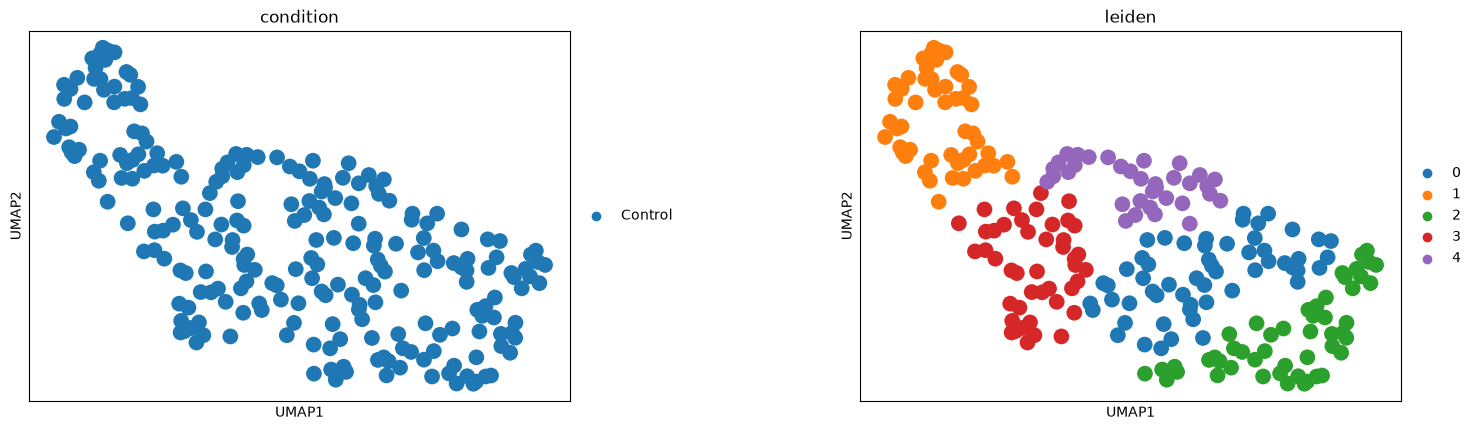

In [40]:
sc.tl.umap(adata_control_hvg_lfc)
sc.pl.umap(adata_control_hvg_lfc, color=['condition', 'leiden'], wspace=0.4)

In [41]:
# Train Test split with 10 from each leiden cluster
selected_pert_indices = []
for cluster in adata_control_hvg_lfc.obs['leiden'].unique():
    cluster_indices = adata_control_hvg_lfc.obs[adata_control_hvg_lfc.obs['leiden'] == cluster].index
    if len(cluster_indices) >= 10:
        selected_pert_indices.extend(np.random.choice(cluster_indices, size=10, replace=False))
    else:
        selected_pert_indices.extend(cluster_indices)

adata_control_hvg_lfc_sub = adata_control_hvg_lfc[selected_pert_indices].copy()

In [44]:
X_train, X_test, y_train, y_test = train_test_split(adata_control_hvg_lfc_sub.X, adata_control_hvg_lfc_sub.obs['condition'], test_size=0.2, random_state=42, stratify=adata_control_hvg_lfc_sub.obs['condition'])

## Predict the log2 fold change

In [ ]:
# Task: Predict log2 fold changes for perturbations
#
# INPUT:
# A. basline expression of the perturbed gene in the control condition
# B. one hot encoded vector with pathway-level information for the perturbed gene + on hot encoded condition information
# C. Gene embeddings from a pre-trained foundation model
# D. CITE-seq MOFA embeddings
#
# Learning algrithm: 
# A. Random Forest Regressor
# B. Ridge Regression
# C. GEARS perturbation prediction model
# D. (KNN, lasso)
#
# Controls:
# Negative:
# No Change: Constant prediction of zero (∆ ̂= 0)
# Train Mean: Average expression change of training perturbations
# Random: Uniform random numbers (0 to 1) as dummy embeddings
#
# Idealized:
# Global PCA on all perturbations (data leakage)
# 
# OUTPUT:
# Mean log2 fold-change profile across 2,000 genes
#
# DATA SPLIT:
#   40 unique perturbations for training
#   10 unique perturbations for testing